# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Regression Discontinuity Design for Top Movers List

---
## Foreword

In this notebook, my goal is to replicate the design of Barber et al. (2022) that demonstrates the influence of the app feature's Top Movers List on the trading behavior of Robinhood's users.


## 1. Libraries & Data

I first load the relevant libraries and data.

In [ ]:
# libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels import OLS
from linearmodels.panel import PanelOLS
import statsmodels.formula.api as smf

Once the libraries are ready, I import the data.

In [185]:
# baseline trading sample
df = pd.read_csv('../../../data/processed/baseline_trading_sample.csv')

# parse dates
df['date'] = pd.to_datetime(df['date'])

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_22371/4266781822.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../../data/processed/baseline_trading_sample.csv')


In [186]:
assert not df.duplicated(subset=["date", "ticker"]).any(), "df is not unique at the date-ticker level"

In [187]:
# assert that the column 'userchg_intraday' is present in the data frame
assert "userchg_intraday" in df.columns, "userchg_intraday column is not present in the data frame"

In [188]:
# number of unique tickers
num_tickers = df['ticker'].nunique()
print(f"Number of unique tickers: {num_tickers}")

Number of unique tickers: 8272


## 2. Reproducing Early Findings

### 2.1. Variables Construction

In this section, I build the relevant variables needed for my analysis.

In [ ]:
df = df.sort_values(['ticker', 'date']).copy()

# market cap at market open in millions
df['shrout_lag1'] = df.groupby('ticker')['shrout'].shift(1)
df['mktcap'] = (df['open_price'] * df['shrout_lag1']) / 1e3

# desribe mktcap
print(df['mktcap'].describe())

# overnight return from previous close to today's open
df["close_price_lag"] = df.groupby("ticker")["close_price"].shift(1)
df["overnight_ret"] = (df["open_price"] / df["close_price_lag"]) - 1

# absolute overnight return
df["abs_overnight_ret"] = df["overnight_ret"].abs()

# absolute return
df["abs_ret"] = df['ret'].abs()

# absolute intra ret
df['intra_ret'] = (df['close_price'] / df['open_price']) - 1
df['abs_intra_ret'] = df['intra_ret'].abs()

# winsorize userchg_intraday and net_buys at 0.2 and 99.8 percentiles
df["userchg_intraday"] = df["userchg_intraday"].clip(
    lower=df["userchg_intraday"].quantile(0.002),
    upper=df["userchg_intraday"].quantile(0.998)
)
df["net_buys"] = df["net_buys"].clip(
    lower=df["net_buys"].quantile(0.002),
    upper=df["net_buys"].quantile(0.998)
)

count    3.736584e+06
mean     5.637341e+03
std      3.108109e+04
min      2.000000e-03
25%      9.542111e+01
50%      4.503114e+02
75%      2.274703e+03
max      1.958240e+06
Name: mktcap, dtype: float64


In [190]:
df.columns.tolist()

['date',
 'users_close',
 'users_start',
 'users_last',
 'intraday_userchg',
 'ticker',
 'permno',
 'ret',
 'prc',
 'vol',
 'shrout',
 'exchcd',
 'symro',
 'symsu',
 'buy_num_trades_LR',
 'sell_num_trades_LR',
 'total_trade_LR',
 'buy_vol_LR',
 'sell_vol_LR',
 'close_price',
 'open_price',
 'close_vol',
 'open_vol',
 'total_vol_m',
 'total_n_trades_m',
 'intra_ret',
 'buy_num_trades_tick',
 'sell_num_trades_tick',
 'buy_vol_tick',
 'sell_vol_tick',
 'total_trade_tick',
 'buy_num_trades_wrds',
 'sell_num_trades_wrds',
 'buy_vol_wrds',
 'sell_vol_wrds',
 'total_trade_wrds',
 'bs_ratio_num',
 'bs_ratio_vol',
 'buy_num_trades_retail',
 'sell_num_trades_retail',
 'buy_vol_retail',
 'sell_vol_retail',
 'total_trade_retail',
 'total_vol_retail',
 'bs_ratio_retail_vol',
 'bs_ratio_retail_num',
 'intra_volatility',
 'buy_num_trades_inst50k',
 'sell_num_trades_inst50k',
 'buy_vol_inst50k',
 'sell_vol_inst50k',
 'total_trade_inst50k',
 'total_vol_inst50k',
 'bs_ratio_inst50k_vol',
 'bs_ratio_inst

I build the residuals $\varepsilon_{i, t}$ of the variable `intraday_userchg` when regressed on fixed date and stock effect:

$$
{\textit{userchg\_intraday}}_{i, t} = \alpha_i + \delta_t + \varepsilon_{i, t}
$$

In [191]:
# copy
df_res = df.copy()

# force dependent variable to numeric
df_res["userchg_intraday"] = pd.to_numeric(df_res["userchg_intraday"], errors="coerce")

# drop missing values in variables used here
df_res = df_res.dropna(subset=["ticker", "date", "userchg_intraday"]).copy()

# set panel index
df_res = df_res.set_index(["ticker", "date"]).sort_index()

# estimate FE model
model = PanelOLS.from_formula(
    "userchg_intraday ~ 1 + EntityEffects + TimeEffects",
    data=df_res
)

results = model.fit()

# save residuals
df_res["userchg_intraday_resid"] = results.resids

# bring keys back as columns
residuals = (
    df_res[["userchg_intraday_resid"]]
    .reset_index()
)

# merge back to original dataframe using ticker and date
df = df.merge(
    residuals,
    on=["ticker", "date"],
    how="left"
)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_22371/2579707430.py:19: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results = model.fit()


### Reproducing Early Findings

I create a plot of the average number of Intraday User change for Robinhood depending on the rank of the return.

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_22371/1300158721.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: summarize_cell(x, "userchg_intraday"))
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_22371/1300158721.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: summarize_cell(x, "net_buys"))


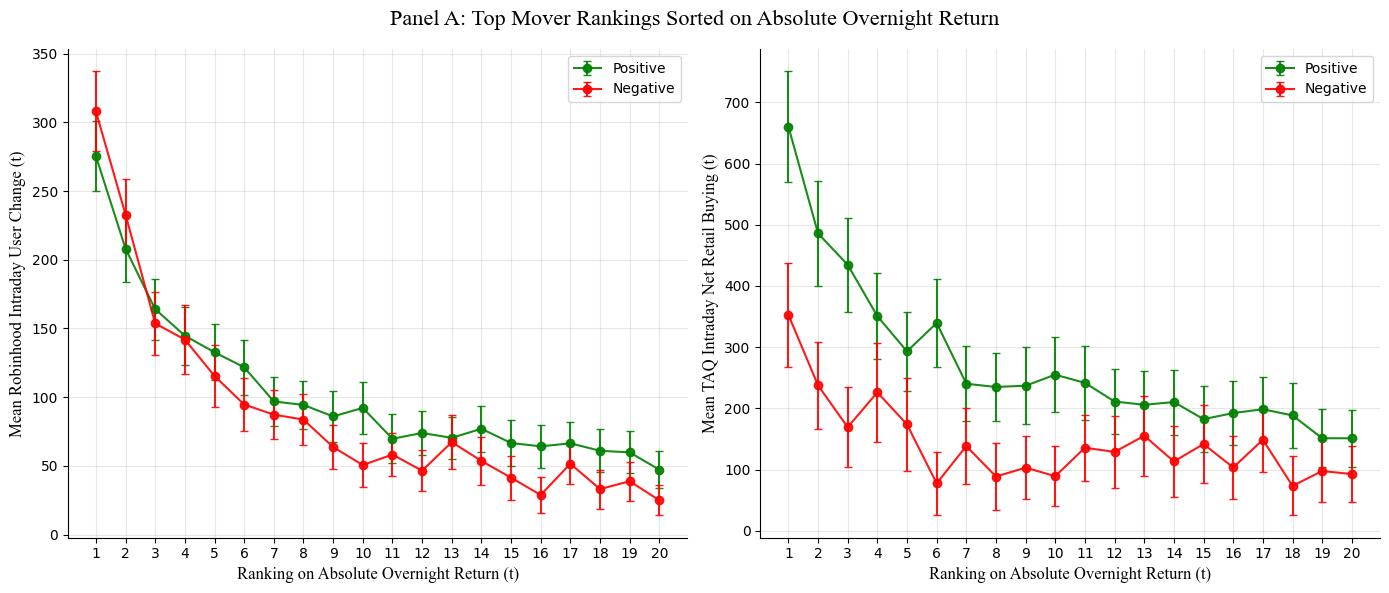

In [229]:
# ------------------------------------------------------------
# 1. PREPARE THE SAMPLE
# ------------------------------------------------------------
df_plot = df.copy()

# Keep only the variables needed
cols = [
    "date",
    "ticker",
    "mktcap",                      # market cap at market open of day t
    "overnight_ret",               # close(t-1) to open(t)
    "ret",                         # close(t) / close(t-1) - 1
    "userchg_intraday",            # user change from open to close of day t
    "net_buys",
    "userchg",                      # user change from open to close of day t
    "userchg_intraday_resid"         # residualized user change from open to close of day t

]
df_plot = df_plot[cols].dropna(subset=cols).copy()

# Keep stocks above $300m at the market open
df_plot = df_plot[(df_plot["mktcap"] > 300)].copy()

# ------------------------------------------------------------
# 2. RANKING BASED ON ABSOLUTE OVERNIGHT RETURN
# ------------------------------------------------------------
df_plot["abs_ret"] = df_plot["overnight_ret"].abs()

# rank 1 = biggest absolute overnight return
df_plot["rank"] = (
    df_plot.groupby("date")["abs_ret"]
           .rank(method="first", ascending=False)
)

# keep top 20
df_plot = df_plot[df_plot["rank"] <= 20].copy()

# sign split
df_plot = df_plot[df_plot["overnight_ret"] != 0].copy()
df_plot["ret_sign"] = np.where(df_plot["overnight_ret"] > 0, "Positive", "Negative")

# ------------------------------------------------------------
# 3. COMPUTE MEANS AND 90% CONFIDENCE INTERVALS
# ------------------------------------------------------------
def summarize_cell(x, value_col):
    n = x[value_col].notna().sum()
    mean = x[value_col].mean()
    se = x[value_col].std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
    ci90 = 1.645 * se if pd.notna(se) else np.nan
    return pd.Series({
        "mean": mean,
        "lower": mean - ci90 if pd.notna(ci90) else np.nan,
        "upper": mean + ci90 if pd.notna(ci90) else np.nan,
        "n": n
    })

rh_sum = (
    df_plot.groupby(["rank", "ret_sign"], as_index=False)
           .apply(lambda x: summarize_cell(x, "userchg_intraday"))
           .reset_index(drop=True)
)

taq_sum = (
    df_plot.groupby(["rank", "ret_sign"], as_index=False)
           .apply(lambda x: summarize_cell(x, "net_buys"))
           .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=False)

for sign, marker, color in [("Positive", "o", "green"), ("Negative", "o", "red")]:
    d1 = rh_sum[rh_sum["ret_sign"] == sign].sort_values("rank")
    axes[0].errorbar(
        d1["rank"], d1["mean"],
        yerr=[d1["mean"] - d1["lower"], d1["upper"] - d1["mean"]],
        fmt=f"-{marker}", capsize=3, label=sign, color=color, alpha=0.9
    )

    d2 = taq_sum[taq_sum["ret_sign"] == sign].sort_values("rank")
    axes[1].errorbar(
        d2["rank"], d2["mean"],
        yerr=[d2["mean"] - d2["lower"], d2["upper"] - d2["mean"]],
        fmt=f"-{marker}", capsize=3, label=sign, color=color, alpha=0.9
    )

#axes[0].set_title("Robinhood Intraday User Change")
axes[0].set_xlabel("Ranking on Absolute Overnight Return (t)", fontsize=12, family="Times New Roman")
axes[0].set_ylabel("Mean Robinhood Intraday User Change (t)", fontsize=12, family="Times New Roman")

#axes[1].set_title("TAQ Intraday Net Retail Buying")
axes[1].set_xlabel("Ranking on Absolute Overnight Return (t)", fontsize=12, family="Times New Roman")
axes[1].set_ylabel("Mean TAQ Intraday Net Retail Buying (t)", fontsize=12, family="Times New Roman")

for ax in axes:
    ax.set_xticks(range(1, 21))
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()

# set a common title for the figure
fig.suptitle("Panel A: Top Mover Rankings Sorted on Absolute Overnight Return", fontsize=16, family="Times New Roman")

plt.tight_layout()
plt.savefig("../../../figures/Panel_A_TopMoverRanking.pdf", bbox_inches="tight")
plt.show()

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_22371/3327925716.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: summarize_cell(x, "userchg_intraday"))
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_22371/3327925716.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: summarize_cell(x, "net_buys"))


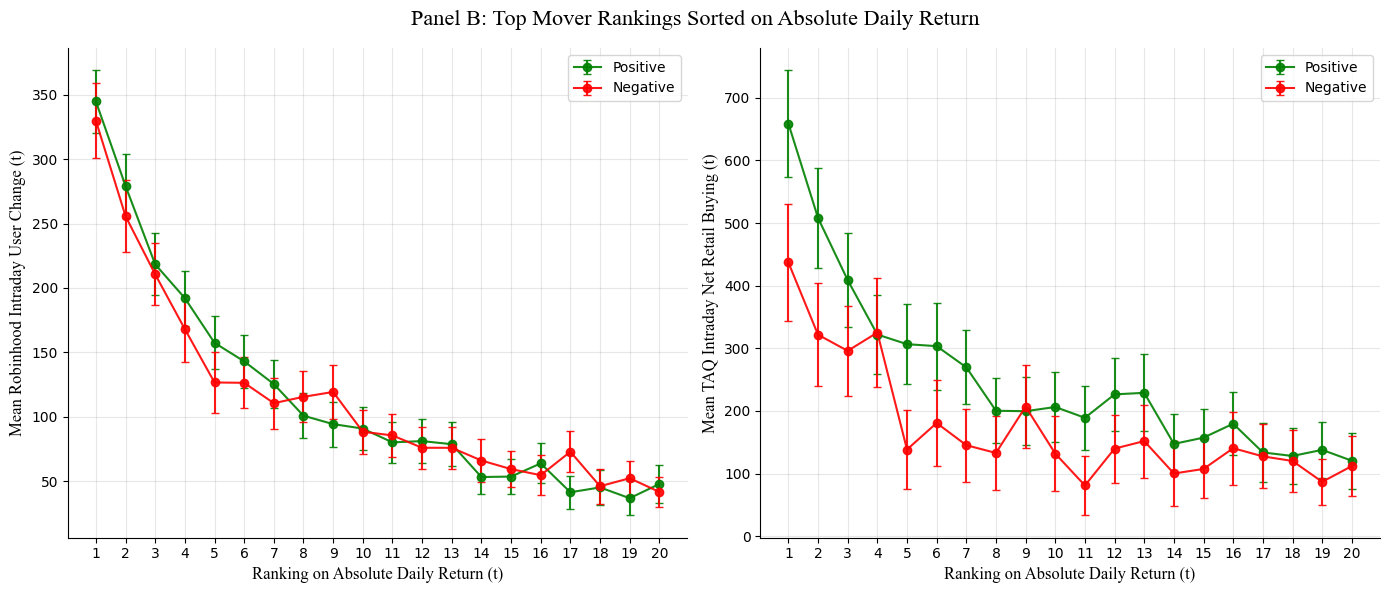

In [230]:
# ------------------------------------------------------------
# 1. PREPARE THE SAMPLE
# ------------------------------------------------------------
df_plot_2 = df.copy()

# Keep only the variables needed
cols = [
    "date",
    "ticker",
    "mktcap",                      # market cap at market open of day t
    "overnight_ret",               # close(t-1) to open(t)
    "ret",                         # close(t) / close(t-1) - 1
    "userchg_intraday",            # user change from open to close of day t
    "net_buys",
    "userchg",                      # user change from open to close of day t
    "userchg_intraday_resid"         # residualized user change from open to close of day t

]
df_plot_2 = df_plot_2[cols].dropna(subset=cols).copy()

# Keep stocks above $300m at the market open
df_plot_2 = df_plot_2[(df_plot_2["mktcap"] > 300)].copy()

# ------------------------------------------------------------
# 2. RANKING BASED ON ABSOLUTE OVERNIGHT RETURN
# ------------------------------------------------------------
df_plot_2["abs_ret"] = df_plot_2["ret"].abs()

# rank 1 = biggest absolute overnight return
df_plot_2["rank"] = (
    df_plot_2.groupby("date")["abs_ret"]
           .rank(method="first", ascending=False)
)

# keep top 20
df_plot_2 = df_plot_2[df_plot_2["rank"] <= 20].copy()

# sign split
df_plot_2 = df_plot_2[df_plot_2["ret"] != 0].copy()
df_plot_2["ret_sign"] = np.where(df_plot_2["ret"] > 0, "Positive", "Negative")

# ------------------------------------------------------------
# 3. COMPUTE MEANS AND 90% CONFIDENCE INTERVALS
# ------------------------------------------------------------
def summarize_cell(x, value_col):
    n = x[value_col].notna().sum()
    mean = x[value_col].mean()
    se = x[value_col].std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
    ci90 = 1.645 * se if pd.notna(se) else np.nan
    return pd.Series({
        "mean": mean,
        "lower": mean - ci90 if pd.notna(ci90) else np.nan,
        "upper": mean + ci90 if pd.notna(ci90) else np.nan,
        "n": n
    })

rh_sum = (
    df_plot_2.groupby(["rank", "ret_sign"], as_index=False)
           .apply(lambda x: summarize_cell(x, "userchg_intraday"))
           .reset_index(drop=True)
)

taq_sum = (
    df_plot_2.groupby(["rank", "ret_sign"], as_index=False)
           .apply(lambda x: summarize_cell(x, "net_buys"))
           .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=False)

for sign, marker, color in [("Positive", "o", "green"), ("Negative", "o", "red")]:
    d1 = rh_sum[rh_sum["ret_sign"] == sign].sort_values("rank")
    axes[0].errorbar(
        d1["rank"], d1["mean"],
        yerr=[d1["mean"] - d1["lower"], d1["upper"] - d1["mean"]],
        fmt=f"-{marker}", capsize=3, label=sign, color=color, alpha=0.9
    )

    d2 = taq_sum[taq_sum["ret_sign"] == sign].sort_values("rank")
    axes[1].errorbar(
        d2["rank"], d2["mean"],
        yerr=[d2["mean"] - d2["lower"], d2["upper"] - d2["mean"]],
        fmt=f"-{marker}", capsize=3, label=sign, color=color, alpha=0.9
    )

#axes[0].set_title("Robinhood Intraday User Change")
axes[0].set_xlabel("Ranking on Absolute Daily Return (t)", fontsize=12, family="Times New Roman")
axes[0].set_ylabel("Mean Robinhood Intraday User Change (t)", fontsize=12, family="Times New Roman")

#axes[1].set_title("TAQ Intraday Net Retail Buying")
axes[1].set_xlabel("Ranking on Absolute Daily Return (t)", fontsize=12, family="Times New Roman")
axes[1].set_ylabel("Mean TAQ Intraday Net Retail Buying (t)", fontsize=12, family="Times New Roman")

for ax in axes:
    ax.set_xticks(range(1, 21))
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()

# set a common title for the figure
fig.suptitle("Panel B: Top Mover Rankings Sorted on Absolute Daily Return", fontsize=16, family="Times New Roman")

plt.tight_layout()
plt.savefig("../../../figures/Panel_B_TopMoverRanking.pdf", bbox_inches="tight")
plt.show()

And the regression

In [196]:
# ------------------------------------------------------------
# 6. FORMAL TEST: BARBER ET AL. (2022)-STYLE REGRESSION
# ------------------------------------------------------------
# Work from the same df_plot sample used for the figure
df_reg = df_plot.copy()

# Barber et al. assign:
# 20 = highest absolute return
#  1 = 20th-highest absolute return
df_reg["score"] = 21 - df_reg["rank"]

# Indicator for negative return
df_reg["neg_ret"] = (df_reg["overnight_ret"] < 0).astype(int)

# Keep only needed columns
df_reg = df_reg[[
    "date",
    "ticker",
    "score",
    "neg_ret",
    "userchg_intraday",
    "net_buys"
]].dropna().copy()

# Make sure date is a datetime
df_reg["date"] = pd.to_datetime(df_reg["date"])

# ------------------------------------------------------------
# 6A. ROBINHOOD REGRESSION
# NetBuy_it = beta0 + beta1*Score_it + beta2*I(R_it<0)
#           + beta3*Score_it*I(R_it<0) + alpha_t + epsilon_it
# ------------------------------------------------------------
rh_mod = smf.ols(
    formula="userchg_intraday ~ score + neg_ret + score:neg_ret + C(date)",
    data=df_reg
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg["date"]}
)

# ------------------------------------------------------------
# 6B. TAQ REGRESSION
# ------------------------------------------------------------
taq_mod = smf.ols(
    formula="net_buys ~ score + neg_ret + score:neg_ret + C(date)",
    data=df_reg
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg["date"]}
)

# ------------------------------------------------------------
# 6C. DISPLAY MAIN COEFFICIENTS
# ------------------------------------------------------------
coef_table = pd.DataFrame({
    "RH coef": rh_mod.params[["score", "neg_ret", "score:neg_ret"]],
    "RH se": rh_mod.bse[["score", "neg_ret", "score:neg_ret"]],
    "RH pval": rh_mod.pvalues[["score", "neg_ret", "score:neg_ret"]],
    "TAQ coef": taq_mod.params[["score", "neg_ret", "score:neg_ret"]],
    "TAQ se": taq_mod.bse[["score", "neg_ret", "score:neg_ret"]],
    "TAQ pval": taq_mod.pvalues[["score", "neg_ret", "score:neg_ret"]],
})

print("\nBarber et al. (2022)-style top-mover regression results")
print(coef_table.round(4))


Barber et al. (2022)-style top-mover regression results
               RH coef   RH se  RH pval  TAQ coef   TAQ se  TAQ pval
score           8.3348  0.5179   0.0000   18.2997   1.7488    0.0000
neg_ret       -25.1657  7.1030   0.0004   14.4645  23.5316    0.5388
score:neg_ret   1.8533  0.6982   0.0079   -8.7441   2.2072    0.0001


In [220]:
# ------------------------------------------------------------
# 6. FORMAL TEST: BARBER ET AL. (2022)-STYLE REGRESSION
# ------------------------------------------------------------
# Work from the same df_plot sample used for the figure
df_reg_2 = df_plot_2.copy()

# Barber et al. assign:
# 20 = highest absolute return
#  1 = 20th-highest absolute return
df_reg_2["score"] = 21 - df_reg_2["rank"]

# Indicator for negative return
df_reg_2["neg_ret"] = (df_reg_2["ret"] < 0).astype(int)

# Keep only needed columns
df_reg_2 = df_reg_2[[
    "date",
    "ticker",
    "score",
    "neg_ret",
    "userchg_intraday",
    "net_buys"
]].dropna().copy()

# Make sure date is a datetime
df_reg_2["date"] = pd.to_datetime(df_reg_2["date"])

# ------------------------------------------------------------
# 6A. ROBINHOOD REGRESSION
# NetBuy_it = beta0 + beta1*Score_it + beta2*I(R_it<0)
#           + beta3*Score_it*I(R_it<0) + alpha_t + epsilon_it
# ------------------------------------------------------------
rh_mod = smf.ols(
    formula="userchg_intraday ~ score + neg_ret + score:neg_ret + C(date)",
    data=df_reg_2
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg_2["date"]}
)

# ------------------------------------------------------------
# 6B. TAQ REGRESSION
# ------------------------------------------------------------
taq_mod = smf.ols(
    formula="net_buys ~ score + neg_ret + score:neg_ret + C(date)",
    data=df_reg_2
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg_2["date"]}
)

# ------------------------------------------------------------
# 6C. DISPLAY MAIN COEFFICIENTS
# ------------------------------------------------------------
coef_table = pd.DataFrame({
    "RH coef": rh_mod.params[["score", "neg_ret", "score:neg_ret"]],
    "RH se": rh_mod.bse[["score", "neg_ret", "score:neg_ret"]],
    "RH pval": rh_mod.pvalues[["score", "neg_ret", "score:neg_ret"]],
    "TAQ coef": taq_mod.params[["score", "neg_ret", "score:neg_ret"]],
    "TAQ se": taq_mod.bse[["score", "neg_ret", "score:neg_ret"]],
    "TAQ pval": taq_mod.pvalues[["score", "neg_ret", "score:neg_ret"]],
})

print("\nBarber et al. (2022)-style top-mover regression results")
print(coef_table.round(4))


Barber et al. (2022)-style top-mover regression results
               RH coef   RH se  RH pval  TAQ coef   TAQ se  TAQ pval
score          12.8722  0.5578   0.0000   19.9989   1.7311    0.0000
neg_ret        38.8560  8.0687   0.0000   60.4367  25.5506    0.0180
score:neg_ret  -1.9274  0.7288   0.0082   -6.9353   2.2521    0.0021


In both the Robinhood and TAQ samples, buying activity increases monotonically with top-mover score, indicating that investors concentrate their purchases in the most extreme movers. However, the response is significantly weaker for negative-return stocks, as shown by the negative and highly significant interaction between score and the negative-return indicator. This asymmetry is materially larger in the TAQ sample than in the Robinhood sample, implying that Robinhood users are less averse than other retail investors to buying top losers.

## 3. Regression Discontinuity Design

### 3.1. Variables Construction

Now, I start again with the raw dataset and build relevant variables.

In [281]:
# baseline trading sample
df2 = pd.read_csv('../../../data/processed/baseline_trading_sample.csv')

# parse dates
df2['date'] = pd.to_datetime(df2['date'])

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_22371/1193190396.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('../../../data/processed/baseline_trading_sample.csv')


Once I loaded the dataset, I continue with the construction of the relevant variables.

In [282]:
df2 = df2.sort_values(['ticker', 'date']).copy()

# market cap at market open in millions
df2['shrout_lag1'] = df2.groupby('ticker')['shrout'].shift(1)
df2['mktcap'] = (df2['open_price'] * df2['shrout_lag1']) / 1e3

# overnight return from previous close to today's open
df2["close_price_lag"] = df2.groupby("ticker")["close_price"].shift(1)
df2["overnight_ret"] = (df2["open_price"] / df2["close_price_lag"]) - 1

# absolute overnight return
df2["abs_overnight_ret"] = df2["overnight_ret"].abs()

# absolute return
df2["abs_ret"] = df2['ret'].abs()

# absolute intra ret
df2['intra_ret'] = (df2['close_price'] / df2['open_price']) - 1
df2['abs_intra_ret'] = df2['intra_ret'].abs()

# winsorize userchg_intraday and net_buys at 0.2 and 99.8 percentiles
df2["userchg_intraday"] = df2["userchg_intraday"].clip(
    lower=df2["userchg_intraday"].quantile(0.005),
    upper=df2["userchg_intraday"].quantile(0.995)
)

### 3.2. Treatment and Control Groups

I now proceed as close as possible from the design of Barber et al. (2022). I respect the following steps ($\textit{mktcap}_{i, t}$ is measured in million of USD):

1. I rank all the stock $i$ that have $\textit{mktcap}_{i, t} > 300$ based on their absolute overnight return $R^{\textit{overnight}}_{i, t}$.
2. I select the treatment group for day $t$ as the stocks with $\textit{mktcap}_{i, t} \in (300, 350] \cap \textit{rank}_{i, t} \leq 20$.
3. I create a control group for day $t$ with stocks with $\textit{mktcap}_{i, t} \in [250, 300]$ that have absolute day-$t$ overnight returns $|R^{\textit{overnight}}_{i, t}|$ close to stocks in the treatment group. Specifically, for each stock in the treatment group, I find a matched stock that has the closest absolute return distance with the treated stock among all stocks with market cap $\in [250, 300]$ and satisfy the following:

    $$
        \frac{R^{\textit{overnight}}_{\textit{treatment}, t}}{R^{\textit{overnight}}_{\textit{control}, t}} \in [0.5, 2]
    $$
4. I then exploit the following sharp regression discontinuity design:
    $$
        \textit{userchg\_intraday}_{i, t} = \beta_0 + \beta_1 \mathbb{1}_{\textit{mktcap}_{i, t} \ge 300} + \sum_{n = 1}^{N} \beta_{2, n} (\textit{mktcap}_{i, t} - 300)^{n} + \sum_{n = 1}^{N} \beta_3 (\textit{mktcap}_{i, t} - 300)^{n} \cdot \mathbb{1}_{\textit{mktcap}_{i, t} \ge 300} + \varepsilon_{i, t}
    $$
    where $\mathbb{1}_{\textit{mktcap}_{i, t} \ge 300}$ is a binary indicator taking the value $1$ when $\textit{mktcap}_{i, t} \ge 300$ and $0$ otherwise. As controls, I include different polynomial functions of market cap $(N = 1, 2, 3)$.

In [283]:
# ============================================================
# REQUIRED COLUMNS IN df
# ------------------------------------------------------------
# date              : trading day
# ticker            : stock identifier
# mktcap            : market capitalization in million USD
# overnight_ret     : overnight return (signed)
# userchg_intraday  : intraday change in Robinhood users
# ============================================================


def build_topmover_rd_sample(
    df,
    upper_treat_cap=350,
    lower_control_cap=250,
    cutoff=300,
    top_n=20,
    ratio_low=0.5,
    ratio_high=2.0,
    keep_all_eligible_controls=True
):
    """
    Build an RD sample inspired by Barber et al. (2022):
    - Treated-side candidates:
        market cap in (300, upper_treat_cap]
        AND top_n by abs overnight return among stocks with mktcap > 300
    - Control-side candidates:
        market cap in [lower_control_cap, 300]
        AND abs overnight return sufficiently close to at least one treated-side candidate
          using the ratio restriction:
              abs_ret_treated / abs_ret_control in [ratio_low, ratio_high]

    Important:
    This function uses the return-based matching logic only as a SAMPLE RESTRICTION.
    The regression itself will still estimate the discontinuity at the 300 cutoff.

    Parameters
    ----------
    df : pd.DataFrame
    upper_treat_cap : float
        Upper cap bound for treated-side sample.
    lower_control_cap : float
        Lower cap bound for below-cutoff controls.
    cutoff : float
        RD threshold, usually 300.
    top_n : int
        Number of top absolute-return movers above the cutoff to keep.
    ratio_low, ratio_high : float
        Allowed range for abs_ret_treated / abs_ret_control.
    keep_all_eligible_controls : bool
        If True, keep every below-cutoff stock that matches at least one treated stock.
        If False, keep only the single closest treated-return distance match for each control.

    Returns
    -------
    rd_df : pd.DataFrame
        Restricted RD sample.
    """

    data = df.copy()
    data = data.dropna(subset=["date", "ticker", "mktcap", "overnight_ret", "userchg_intraday"]).copy()
    data["date"] = pd.to_datetime(data["date"])
    data["abs_overnight_ret"] = data["overnight_ret"].abs()

    out = []

    for d, g in data.groupby("date"):
        g = g.copy()

        # --------------------------------------------------------
        # 1. Above-threshold ranking among stocks with mktcap > cutoff
        # --------------------------------------------------------
        eligible_above = g[g["mktcap"] > cutoff].copy()
        if eligible_above.empty:
            continue

        eligible_above = eligible_above.sort_values("abs_overnight_ret", ascending=False)
        eligible_above["rank_above_cutoff"] = np.arange(1, len(eligible_above) + 1)

        treated = eligible_above[
            (eligible_above["mktcap"] > cutoff) &
            (eligible_above["mktcap"] <= upper_treat_cap) &
            (eligible_above["rank_above_cutoff"] <= top_n)
        ].copy()

        if treated.empty:
            continue

        treated["sample_side"] = "above"
        treated["rd_treated"] = 1

        # --------------------------------------------------------
        # 2. Below-threshold comparable controls
        # --------------------------------------------------------
        controls_pool = g[
            (g["mktcap"] >= lower_control_cap) &
            (g["mktcap"] <= cutoff)
        ].copy()

        if controls_pool.empty:
            continue

        matched_controls_idx = set()
        control_best_distance = {}

        treated_abs = treated["abs_overnight_ret"].to_numpy()

        for idx, row in controls_pool.iterrows():
            c_abs = row["abs_overnight_ret"]

            # Zero-handling
            if c_abs == 0:
                valid = np.where(treated_abs == 0)[0]
                if len(valid) == 0:
                    continue
                min_dist = 0.0
            else:
                ratios = treated_abs / c_abs
                valid = np.where((ratios >= ratio_low) & (ratios <= ratio_high))[0]
                if len(valid) == 0:
                    continue
                min_dist = np.min(np.abs(treated_abs[valid] - c_abs))

            matched_controls_idx.add(idx)
            control_best_distance[idx] = min_dist

        if not matched_controls_idx:
            continue

        controls = controls_pool.loc[list(matched_controls_idx)].copy()
        controls["best_treated_absret_distance"] = controls.index.map(control_best_distance)
        controls["sample_side"] = "below"
        controls["rd_treated"] = 0

        if not keep_all_eligible_controls:
            # Optional tighter restriction:
            # for each day, keep only the most comparable below-threshold stocks
            controls = controls.sort_values("best_treated_absret_distance").copy()

        # --------------------------------------------------------
        # 3. Stack into daily RD sample
        # --------------------------------------------------------
        day_sample = pd.concat([treated, controls], axis=0, ignore_index=True)
        out.append(day_sample)

    if not out:
        return pd.DataFrame()

    rd_df = pd.concat(out, axis=0, ignore_index=True)

    # Running variable centered at cutoff
    rd_df["running"] = rd_df["mktcap"] - cutoff

    return rd_df


def run_rd_on_restricted_sample(
    rd_df,
    outcome="userchg_intraday",
    cutoff=300,
    degree=1,
    cluster="date"
):
    """
    Estimate:
        outcome_it = beta0
                   + beta1 * 1(mktcap >= cutoff)
                   + polynomial in (mktcap - cutoff)
                   + interactions with 1(mktcap >= cutoff)
                   + error_it

    on the restricted RD sample produced above.

    Parameters
    ----------
    rd_df : pd.DataFrame
    outcome : str
        Dependent variable.
    cutoff : float
        RD cutoff.
    degree : int
        Polynomial degree for the running variable.
    cluster : str or None
        If 'date', cluster SE by date.
        If None, use HC1 robust SE.

    Returns
    -------
    results : statsmodels result
    """

    if rd_df.empty:
        raise ValueError("rd_df is empty. No restricted RD sample was created.")

    df_reg = rd_df.copy()
    df_reg["D"] = (df_reg["mktcap"] >= cutoff).astype(int)

    # Polynomial terms
    for n in range(1, degree + 1):
        df_reg[f"run{n}"] = df_reg["running"] ** n

    rhs = ["D"]
    for n in range(1, degree + 1):
        rhs.append(f"run{n}")
        rhs.append(f"D:run{n}")

    formula = f"{outcome} ~ " + " + ".join(rhs)
    model = smf.ols(formula, data=df_reg)

    if cluster == "date":
        results = model.fit(
            cov_type="cluster",
            cov_kwds={"groups": df_reg["date"]}
        )
    else:
        results = model.fit(cov_type="HC1")

    return results


def rd_diagnostics(rd_df):
    """
    Basic diagnostics for the restricted sample.
    """
    if rd_df.empty:
        print("RD sample is empty.")
        return

    print("Total observations:", len(rd_df))
    print("Above-cutoff observations:", (rd_df["mktcap"] > 300).sum())
    print("Below-cutoff observations:", (rd_df["mktcap"] <= 300).sum())
    print("Unique dates:", rd_df["date"].nunique())
    print("Unique tickers:", rd_df["ticker"].nunique())

    print("\nMarket cap summary by side:")
    print(rd_df.groupby("sample_side")["mktcap"].describe())

    print("\nAbsolute overnight return summary by side:")
    print(rd_df.groupby("sample_side")["abs_overnight_ret"].describe())


# ============================================================
# EXAMPLE USAGE
# ============================================================

# 1. Build restricted RD sample
rd_df = build_topmover_rd_sample(
    df2,
    upper_treat_cap=350,
    lower_control_cap=250,
    cutoff=300,
    top_n=20,
    ratio_low=0.5,
    ratio_high=2.0,
    keep_all_eligible_controls=True
)

# 2. Diagnostics
rd_diagnostics(rd_df)

# 3. Estimate RD with different polynomial orders
res_lin = run_rd_on_restricted_sample(rd_df, outcome="userchg_intraday", degree=1, cluster="date")
res_quad = run_rd_on_restricted_sample(rd_df, outcome="userchg_intraday", degree=2, cluster="date")
res_cubic = run_rd_on_restricted_sample(rd_df, outcome="userchg_intraday", degree=3, cluster="date")

print("\n================ LINEAR RD ================\n")
print(res_lin.summary())

print("\n================ QUADRATIC RD ================\n")
print(res_quad.summary())

print("\n================ CUBIC RD ================\n")
print(res_cubic.summary())

Total observations: 2812
Above-cutoff observations: 745
Below-cutoff observations: 2067
Unique dates: 377
Unique tickers: 946

Market cap summary by side:
              count        mean        std        min         25%        50%  \
sample_side                                                                    
above         745.0  325.112404  14.702734  300.02011  312.042160  325.65500   
below        2067.0  273.916505  14.243080  250.02500  261.827515  273.08424   

                   75%        max  
sample_side                        
above        338.20956  349.95324  
below        285.82421  300.00000  

Absolute overnight return summary by side:
              count      mean       std       min       25%       50%  \
sample_side                                                             
above         745.0  0.156417  1.051168  0.008055  0.053719  0.080693   
below        2067.0  0.065477  0.055125  0.006154  0.032898  0.050040   

                  75%        max  
sample_s

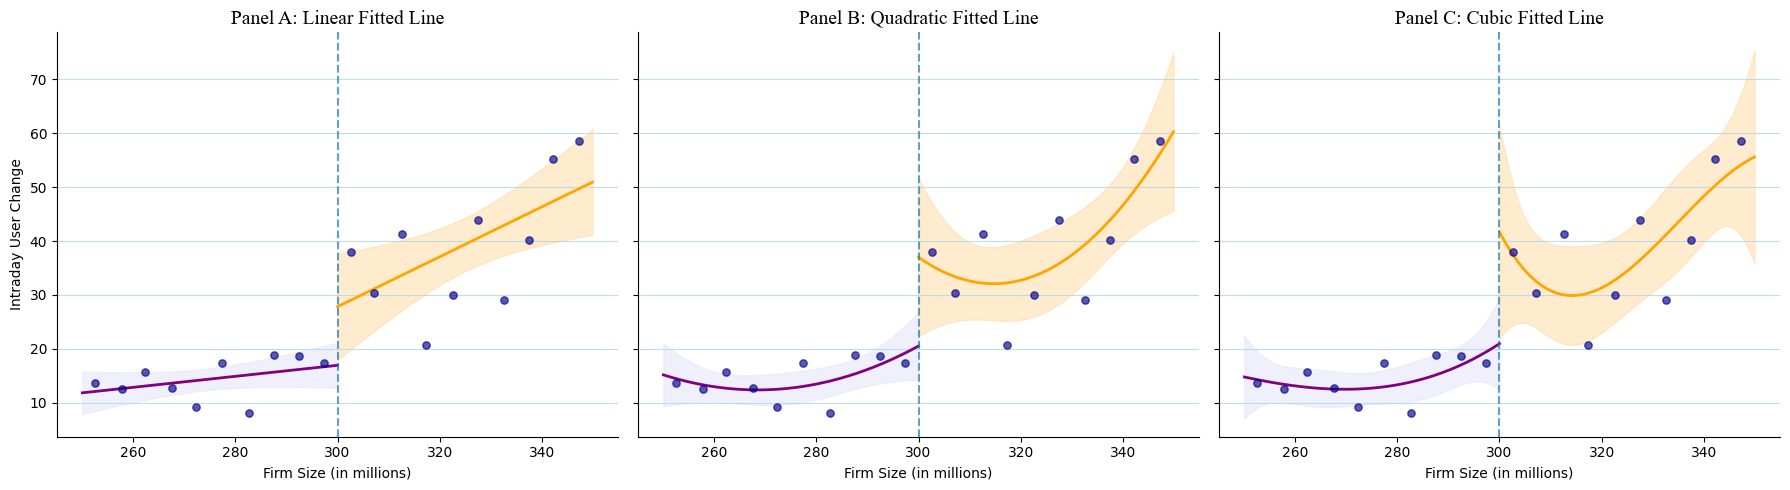

In [284]:
def _make_binned_scatter(
    df,
    x_col="mktcap",
    y_col="userchg_intraday",
    cutoff=300,
    n_bins_each_side=10
):
    """
    Create binned scatterplot data separately below and above the cutoff.
    Returns one dataframe with bin-level mean x and mean y.
    """
    d = df[[x_col, y_col]].dropna().copy()

    below = d[d[x_col] <= cutoff].copy()
    above = d[d[x_col] > cutoff].copy()

    binned_parts = []

    # Below-cutoff bins
    if len(below) > 0:
        below["bin"] = pd.cut(
            below[x_col],
            bins=np.linspace(below[x_col].min(), cutoff, n_bins_each_side + 1),
            include_lowest=True,
            duplicates="drop"
        )
        b0 = below.groupby("bin", observed=False).agg(
            x_mean=(x_col, "mean"),
            y_mean=(y_col, "mean"),
            n=(y_col, "size")
        ).dropna().reset_index(drop=True)
        binned_parts.append(b0)

    # Above-cutoff bins
    if len(above) > 0:
        above["bin"] = pd.cut(
            above[x_col],
            bins=np.linspace(cutoff, above[x_col].max(), n_bins_each_side + 1),
            include_lowest=True,
            duplicates="drop"
        )
        b1 = above.groupby("bin", observed=False).agg(
            x_mean=(x_col, "mean"),
            y_mean=(y_col, "mean"),
            n=(y_col, "size")
        ).dropna().reset_index(drop=True)
        binned_parts.append(b1)

    if not binned_parts:
        return pd.DataFrame(columns=["x_mean", "y_mean", "n"])

    return pd.concat(binned_parts, ignore_index=True)


def _fit_side_polynomial(side_df, degree, x_col="mktcap", y_col="userchg_intraday"):
    """
    Fit polynomial regression separately on one side of the cutoff:
        y = beta0 + beta1*x + beta2*x^2 + ...
    Returns fitted model.
    """
    d = side_df[[x_col, y_col]].dropna().copy()

    X = pd.DataFrame({"const": 1.0}, index=d.index)
    for p in range(1, degree + 1):
        X[f"x{p}"] = d[x_col] ** p

    model = sm.OLS(d[y_col], X).fit()
    return model


def _predict_side(model, x_grid, degree):
    """
    Get fitted values and 90% CI on a grid for one side.
    """
    Xg = pd.DataFrame({"const": np.ones(len(x_grid))})
    for p in range(1, degree + 1):
        Xg[f"x{p}"] = x_grid ** p

    pred = model.get_prediction(Xg).summary_frame(alpha=0.10)  # 90% CI
    out = pd.DataFrame({
        "x": x_grid,
        "yhat": pred["mean"].to_numpy(),
        "ci_low": pred["mean_ci_lower"].to_numpy(),
        "ci_high": pred["mean_ci_upper"].to_numpy()
    })
    return out


def plot_barber_figure5_style(
    rd_df,
    x_col="mktcap",
    y_col="userchg_intraday",
    cutoff=300,
    degrees=(1, 2, 3),
    n_bins_each_side=10,
    figsize=(18, 5),
    point_alpha=0.65,
    line_width=2.0,
    ci_alpha=0.6
):
    """
    Reproduce a Figure 5 style RD plot:
    - binned scatterplot
    - separate fits below/above cutoff
    - 90% confidence bands
    - linear, quadratic, cubic panels on one row
    """

    d = rd_df[[x_col, y_col]].dropna().copy()

    # Binned scatter data
    binned = _make_binned_scatter(
        d,
        x_col=x_col,
        y_col=y_col,
        cutoff=cutoff,
        n_bins_each_side=n_bins_each_side
    )

    below = d[d[x_col] <= cutoff].copy()
    above = d[d[x_col] > cutoff].copy()

    fig, axes = plt.subplots(1, len(degrees), figsize=figsize, sharey=True)

    if len(degrees) == 1:
        axes = [axes]

    panel_titles = {
        1: "Panel A: Linear Fitted Line",
        2: "Panel B: Quadratic Fitted Line",
        3: "Panel C: Cubic Fitted Line"
    }

    for ax, deg in zip(axes, degrees):
        # ----------------------------------------------------
        # 1. Binned scatter
        # ----------------------------------------------------
        ax.scatter(
            binned["x_mean"],
            binned["y_mean"],
            alpha=point_alpha,
            s=28,
            color="darkblue",
            zorder=3
        )

        # ----------------------------------------------------
        # 2. Separate polynomial fits below and above cutoff
        # ----------------------------------------------------
        if len(below) > 0:
            model_below = _fit_side_polynomial(below, degree=deg, x_col=x_col, y_col=y_col)
            xg_below = np.linspace(below[x_col].min(), cutoff, 200)
            pred_below = _predict_side(model_below, xg_below, degree=deg)

            ax.plot(pred_below["x"], pred_below["yhat"], linewidth=line_width, color="purple")
            ax.fill_between(
                pred_below["x"],
                pred_below["ci_low"],
                pred_below["ci_high"],
                alpha=ci_alpha,
                color="lavender"
            )

        if len(above) > 0:
            model_above = _fit_side_polynomial(above, degree=deg, x_col=x_col, y_col=y_col)
            xg_above = np.linspace(cutoff, above[x_col].max(), 200)
            pred_above = _predict_side(model_above, xg_above, degree=deg)

            ax.plot(pred_above["x"], pred_above["yhat"], linewidth=line_width, color="orange")
            ax.fill_between(
                pred_above["x"],
                pred_above["ci_low"],
                pred_above["ci_high"],
                alpha=ci_alpha,
                color="navajowhite"
            )

        # ----------------------------------------------------
        # 3. Cutoff line and formatting
        # ----------------------------------------------------
        ax.axvline(cutoff, linestyle="--", alpha=0.7)
        ax.set_title(panel_titles.get(deg, f"Degree {deg}"), fontsize=14, family="Times New Roman")
        ax.set_xlabel("Firm Size (in millions)")
        ax.grid(axis="y", alpha=0.8, color="lightblue")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Intraday User Change")

    plt.tight_layout()
    plt.savefig("../../../figures/Barber_Figure5_Style_RD.pdf", bbox_inches="tight")
    plt.show()


# ============================================================
# RUN THE FIGURE
# ============================================================

plot_barber_figure5_style(
    rd_df,
    x_col="mktcap",
    y_col="userchg_intraday",
    cutoff=300,
    degrees=(1, 2, 3),
    n_bins_each_side=10,   # 10 bins below + 10 bins above, close to the published figure
    figsize=(18, 5)
)